# Example: Stochastic Attention on MNIST Digits
In this example, we apply the stochastic attention update (Algorithm 1 from L8a) to MNIST handwritten digit images. We store examples of a user-selected digit as memories in a modern Hopfield network and then explore the retrieval-to-generation spectrum by sweeping the inverse temperature parameter $\beta$.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Build a memory matrix from MNIST digits:__ Select examples of a specific digit class, flatten and normalize the images into column vectors, and assemble the memory matrix $\mathbf{X}$ for the modern Hopfield network.
> * __Retrieve a stored memory from a corrupted input:__ Apply deterministic gradient descent on the Hopfield energy to recover a stored digit image from a corrupted initial state, verifying that the network performs associative memory retrieval.
> * __Explore the retrieval-generation spectrum via $\beta$:__ Sweep the inverse temperature from high (sharp retrieval) to low (diverse generation) and visualize the resulting samples in a grid, observing the transition from exact recall to creative generation.

Let's get started!

___

## Background: Stochastic Attention Update
The stochastic attention update adds calibrated noise to the modern Hopfield retrieval map. Given a memory matrix $\mathbf{X}\in\mathbb{R}^{N\times K}$, inverse temperature $\beta > 0$, and step size $\eta\in(0,1]$, the update rule is:

> **Algorithm 1 (Stochastic Attention Update).** Repeat for $t = 0,1,2,\ldots$:
> $$\mathbf{s}^{t+1} = \underbrace{(1-\eta)\mathbf{s}^{t}}_{\text{contraction}} + \underbrace{\eta\,\mathbf{X}\operatorname{softmax}(\beta\mathbf{X}^{\top}\mathbf{s}^{t})}_{\text{attention pull}} + \underbrace{\sqrt{\frac{2\eta}{\beta}}\,\boldsymbol{\xi}^{t}}_{\text{noise injection}}$$
> where $\boldsymbol{\xi}^{t}\sim\mathcal{N}(\mathbf{0},\mathbf{I}_{N})$.

When $\beta$ is large, the noise term vanishes and the update reduces to deterministic Hopfield retrieval. When $\beta$ is small, the noise dominates and the system generates diverse samples. The functions `stochastic_attention_update(...)`, `deterministic_attention_update(...)`, `run_stochastic_attention(...)`, and `run_deterministic_attention(...)` in `src/Compute.jl` implement this algorithm.

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations

The notebook uses a local `decode(...)` function to convert flattened state vectors back to image format:

> * `decode(s; number_of_rows, number_of_cols)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. Reshapes the vector, transposes it to match row-major ordering, and clamps values to $[0,1]$ for grayscale display.

In [2]:
function decode(s::Vector{<:Number}; number_of_rows::Int=28, number_of_cols::Int=28)::Array{Float32,2}
    X = reshape(s, number_of_rows, number_of_cols) |> X -> transpose(X) |> Matrix;
    X̂ = clamp.(Float32.(X), 0.0f0, 1.0f0);
    return X̂
end

decode (generic function with 1 method)

### Constants
Let's set some constants that define the problem size and dataset parameters. The comment next to each constant describes its purpose and values:

In [3]:
number_of_examples = 1000;  # how many examples per digit to load from the MNIST library
number_of_rows = 28;        # number of rows in the image
number_of_cols = 28;        # number of cols in the image
number_of_pixels = number_of_rows * number_of_cols; # total pixels per image (784)

### Load the MNIST digits dataset
We load the MNIST handwritten digit dataset using `MyMNISTHandwrittenDigitImageDataset(...)`. This returns a dictionary where keys are digit labels (0 to 9) and values are 3D arrays of shape $(28, 28, K)$ holding $K$ grayscale images.

In [4]:
digits_image_dictionary = MyMNISTHandwrittenDigitImageDataset(number_of_examples = number_of_examples);

**Pick your digit.** Set `target_digit` to any digit from `0` to `9`. The memory matrix will consist of examples of this digit.

In [5]:
target_digit = 3; # TODO: change this to any digit 0-9

Let's preview a few examples of the selected digit to confirm the data loaded correctly:

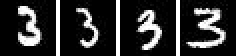

In [6]:
let
    examples = [1, 5, 10, 15]; # which examples to display
    imgs = [Gray.(digits_image_dictionary[target_digit][:, :, i]) for i in examples];
    mosaicview(imgs..., nrow=1, npad=2, fillvalue=Gray(1.0))
end

___

## Task 1: Build the Memory Matrix
In this task, we select $K$ examples of the chosen digit, flatten each $28\times 28$ image to a $784$-element vector, center and normalize each vector, and assemble the memory matrix $\mathbf{X}\in\mathbb{R}^{N\times K}$.

> __Why center and normalize?__ Centering (subtracting the mean) and normalizing (dividing by the $\ell_{2}$-norm) ensures that all memories contribute equally to the softmax attention weights. Without normalization, images with higher overall brightness would dominate the similarity computation.

Let's set the number of memories and build the memory matrix.

In [7]:
K = 64; # number of digit images to store as memories

The code block below builds the memory matrix `X::Matrix{Float32}` and the unnormalized version `X_raw::Matrix{Float32}` (for display).

In [8]:
X, X_raw = let

    # initialize -
    X = Array{Float32,2}(undef, number_of_pixels, K);
    X_raw = Array{Float32,2}(undef, number_of_pixels, K);
    ϵ = 1e-12 |> Float32; # small number to avoid division by zero
    image_data = digits_image_dictionary[target_digit]; # 28 × 28 × number_of_examples

    for k ∈ 1:K
        # flatten: row-major ordering (transpose then reshape)
        s_raw = reshape(transpose(image_data[:, :, k]) |> Matrix, number_of_pixels) |> vec |> x -> convert.(Float32, x);
        X_raw[:, k] = s_raw;

        # center and normalize
        s_centered = s_raw .- mean(s_raw);
        s_normalized = s_centered ./ (norm(s_centered, 2) + ϵ);
        X[:, k] = s_normalized;
    end

    X, X_raw
end;

__Check:__ Let's verify the memory matrix by decoding a few stored memories back to images.

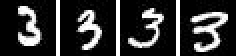

In [9]:
let
    indices = [1, 10, 20, 30]; # which columns to display
    imgs = [decode(X_raw[:, i]) |> img -> Gray.(img) for i in indices];
    mosaicview(imgs..., nrow=1, npad=2, fillvalue=Gray(1.0))
end

___

## Task 2: Deterministic Retrieval from a Corrupted Input
In this task, we corrupt a stored memory by zeroing out a fraction of its pixels and then use the deterministic attention update (gradient descent on the Hopfield energy, no noise) to recover the original image.

> __The corruption model:__ We keep the first $(1-\theta)\cdot N$ pixels from the original image and set the remaining $\theta\cdot N$ pixels to $0$. The parameter $\theta\in[0,1]$ controls the fraction of corrupted pixels. We apply this corruption to both the raw image (for display) and the normalized image (for the update), then run the deterministic update $\mathbf{s}^{t+1} = (1-\eta)\mathbf{s}^{t} + \eta\,\mathbf{T}(\mathbf{s}^{t})$ to convergence.

Let's set the corruption parameters and build the corrupted initial state.

In [10]:
memory_index = 1;   # which stored memory to corrupt (column index in X)
θ = 0.50;           # fraction of pixels to corrupt
β_retrieval = 10.0; # high β for sharp retrieval
η = 1.0;            # step size (1.0 = full Hopfield update)
T_retrieval = 50;   # number of update steps

Build the corrupted initial states: `ŝ₀` (normalized, for the update) and `s₀_raw` (unnormalized, for display). We zero out the last $\theta\cdot N$ pixels of each.

In [11]:
ŝ₀, s₀_raw = let

    # how many pixels do we keep?
    cutoff = round(Int, (1 - θ) * number_of_pixels);

    # corrupted normalized version (for the update)
    ŝ = copy(X[:, memory_index]);
    ŝ[(cutoff+1):end] .= 0.0f0;

    # corrupted raw version (for display)
    s_raw = copy(X_raw[:, memory_index]);
    s_raw[(cutoff+1):end] .= 0.0f0;

    ŝ, s_raw
end;

What does the corrupted input look like compared to the original?

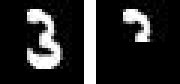

In [12]:
let
    img_original = decode(X_raw[:, memory_index]) |> img -> Gray.(img);
    img_corrupted = decode(s₀_raw) |> img -> Gray.(img);
    mosaicview(img_original, img_corrupted, nrow=1, npad=4, fillvalue=Gray(1.0))
end

Now run the deterministic attention update to recover the stored memory.

In [13]:
s_recovered = run_deterministic_attention(X, ŝ₀, β_retrieval, η, T_retrieval);

Let's compare the original, corrupted, and recovered images side by side. Since the update operates in normalized space, we reconstruct the recovered image by computing the final attention weights $\mathbf{p} = \operatorname{softmax}(\beta\mathbf{X}^{\top}\mathbf{s})$ and applying them to the raw (unnormalized) memory matrix.

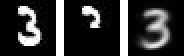

In [14]:
let
    # compute the attention weights at the recovered state
    p = softmax(β_retrieval .* (transpose(X) * s_recovered));
    s_display = X_raw * p; # reconstruct in raw pixel space

    img_original = decode(X_raw[:, memory_index]) |> img -> Gray.(img);
    img_corrupted = decode(s₀_raw) |> img -> Gray.(img);
    img_recovered = decode(s_display) |> img -> Gray.(img);
    mosaicview(img_original, img_corrupted, img_recovered, nrow=1, npad=4, fillvalue=Gray(1.0))
end

___

## Task 3: The Retrieval-to-Generation Spectrum
In this task, we sweep $\beta$ from high (sharp retrieval) to low (diverse generation) and visualize the results in a grid. For each $\beta$ value, we run several independent stochastic attention trajectories from a random initial state and display the final samples.

> __What to expect:__
> * **High $\beta$** (low temperature): The noise amplitude $\sqrt{2\eta/\beta}$ is small. The softmax concentrates on the nearest memory. Samples should look like clean, recognizable digits with little variation.
> * **Low $\beta$** (high temperature): The noise amplitude is large. The softmax spreads across memories. Samples should look like blurred mixtures or novel variations of the digit.
> * **Intermediate $\beta$**: Samples cluster around stored memories but with visible diversity, in the generation regime.

Let's set the sweep parameters.

In [15]:
β_values = [50.0, 10.0, 2.0, 0.5, 0.1]; # inverse temperature sweep (high → low)
number_of_samples = 8;  # independent samples per β value
T_steps = 200;          # number of Langevin steps per sample
η_langevin = 0.5;       # step size for the Langevin update

For each $\beta$ value, we generate `number_of_samples` independent samples by initializing from a random Gaussian state and running the stochastic attention update for `T_steps` iterations.

In [16]:
sample_grid = let

    grid = Dict{Int, Vector{Matrix{Float32}}}();

    for (row, β) in enumerate(β_values)
        row_samples = Vector{Matrix{Float32}}();
        for j in 1:number_of_samples
            # random initial state (small Gaussian)
            s_init = randn(Float32, number_of_pixels) .* 0.01f0;

            # run stochastic attention in normalized space
            s_final = run_stochastic_attention(X, s_init, β, η_langevin, T_steps);

            # map back to raw pixel space via attention weights
            p = softmax(β .* (transpose(X) * s_final));
            s_display = X_raw * p;

            # decode to image
            img = decode(s_display);
            push!(row_samples, img);
        end
        grid[row] = row_samples;
    end

    grid
end;

Let's display the sample grid. Each row corresponds to a different $\beta$ value (labeled on the left), and each column is an independent sample.

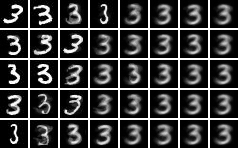

In [17]:
let
    nrows = length(β_values);
    ncols = number_of_samples;

    # build image array for mosaic
    all_imgs = [];
    for row in 1:nrows
        for col in 1:ncols
            push!(all_imgs, Gray.(sample_grid[row][col]));
        end
    end

    mosaicview(all_imgs..., nrow=nrows, npad=2, fillvalue=Gray(1.0))
end

The rows from top to bottom correspond to $\beta$ values:

In [18]:
for (i, β) in enumerate(β_values)
    println("Row $(i): β = $(β)")
end

Row 1: β = 50.0
Row 2: β = 10.0
Row 3: β = 2.0
Row 4: β = 0.5
Row 5: β = 0.1


___

### Signal-to-Noise Ratio (SNR)
The stochastic attention update has a natural per-step signal-to-noise ratio that depends only on the algorithm parameters. At each step, the gradient displacement (the deterministic correction) has magnitude $O(\eta)$, while the noise vector $\sqrt{2\eta/\beta}\,\boldsymbol{\xi}$ has expected magnitude $\sqrt{2\eta N/\beta}$, since $\mathbb{E}[\lVert\boldsymbol{\xi}\rVert_{2}] \approx \sqrt{N}$.

> __Per-step SNR.__ The ratio of the gradient displacement to the expected noise magnitude is:
> $$\text{SNR} = \frac{O(\eta)}{\sqrt{2\eta N/\beta}} = \sqrt{\frac{\eta\beta}{2N}}$$
> where $\eta$ is the step size, $\beta$ is the inverse temperature, and $N$ is the state dimension. This is fully deterministic; it depends only on algorithm parameters and problem dimension. The SNR controls which regime the sampler operates in:
> * **Structured retrieval** ($\text{SNR} \gg \text{SNR}_{\text{transition}}$): The gradient signal dominates and samples remain near stored memories.
> * **Generation** ($\text{SNR} \lesssim \text{SNR}_{\text{transition}}$): Noise dominates and the sampler explores broadly, producing novel outputs.
>
> Synthetic experiments place the transition near $\text{SNR}\approx 0.025$. Given a target SNR, one can solve for $\beta$:
> $$\beta = \frac{2N\cdot\text{SNR}^{2}}{\eta}$$

This gives a dimension-independent $\beta$-selection rule: for our MNIST setup with $N = 784$, the transition SNR of $0.025$ corresponds to $\beta\approx 2$, while operating well inside the retrieval regime (e.g., $\text{SNR} = 0.113$) requires $\beta\approx 2000$. Let's compute the SNR for each $\beta$ in our sweep.

In [ ]:
snr_table = let

    N = number_of_pixels; # state dimension (784)
    η = η_langevin;       # step size

    results = Vector{NamedTuple{(:β, :SNR, :SNR_dB, :regime), 
        Tuple{Float64, Float64, Float64, String}}}();

    SNR_transition = 0.025; # approximate transition from synthetic experiments

    for β in β_values
        SNR = sqrt(η * β / (2.0 * N));
        SNR_dB = 20.0 * log10(SNR); # amplitude ratio → 20 log₁₀
        regime = SNR > SNR_transition ? "retrieval" : "generation";

        # package -
        push!(results, (
            β = β, # inverse temperature
            SNR = SNR, # signal-to-noise ratio
            SNR_dB = SNR_dB, # signal-to-noise ratio in decibels
            regime = regime # retrieval vs. generation regime
        ));
    end

    results # return
end;

Let's display the SNR table and plot the SNR as a function of $\beta$.

In [ ]:
let
    println("N = $(number_of_pixels), η = $(η_langevin), SNR_transition ≈ 0.025")
    println()
    println("β\t\tSNR\t\tSNR (dB)\tRegime")
    println("-" ^ 60)
    for row in snr_table
        println("$(row.β)\t\t$(round(row.SNR, sigdigits=4))\t\t$(round(row.SNR_dB, digits=1))\t\t$(row.regime)")
    end
end

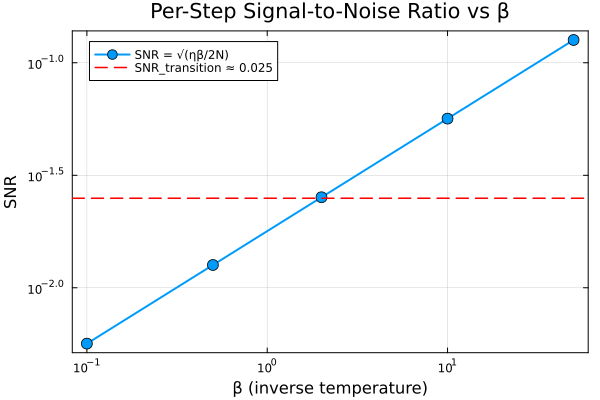

In [21]:
let
    β_plot = [row.β for row in snr_table];
    snr_plot = [row.SNR for row in snr_table];

    p = plot(β_plot, snr_plot, 
        xlabel = "β (inverse temperature)", ylabel = "SNR",
        title = "Per-Step Signal-to-Noise Ratio vs β",
        marker = :circle, markersize = 6, linewidth = 2,
        xscale = :log10, yscale = :log10, legend = :topleft, label = "SNR = √(ηβ/2N)",
        framestyle = :box, grid = true);
    hline!([0.025], linestyle = :dash, color = :red, linewidth = 1.5, 
        label = "SNR_transition ≈ 0.025");
    p
end

The SNR increases as $\sqrt{\beta}$: points above the dashed transition line ($\text{SNR}\approx 0.025$) are in the retrieval regime, while points below are in the generation regime. This matches the visual grid above: high-$\beta$ rows produce sharp digits (retrieval), low-$\beta$ rows produce blurry mixtures (generation). The SNR formula provides a principled way to choose $\beta$ for a given task and dimension.

## Summary
This example applied the stochastic attention update to MNIST digit images, demonstrating how the inverse temperature $\beta$ controls the transition from memory retrieval to sample generation.

> __Key Takeaways:__
>
> * **Memory matrix construction:** Flattening, centering, and normalizing digit images produces a memory matrix suitable for the modern Hopfield energy. The softmax attention weights depend on dot-product similarities, so normalization ensures balanced memory contributions.
> * **Deterministic retrieval works:** At high $\beta$ with no noise, the attention update recovers stored memories from corrupted inputs, matching the behavior of the modern Hopfield retrieval algorithm from L6c.
> * **$\beta$ controls retrieval vs. generation:** High $\beta$ produces sharp recall of individual stored digits. Low $\beta$ generates diverse samples that blend stored memories. The transition is smooth and controlled by a single parameter.

In the lab, we will implement the stochastic attention update from scratch and perform a more detailed quantitative analysis of the retrieval-generation spectrum.

___